In [1]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.dates as mdates

In [158]:
def load_solar():

    data_dir = Path('/g/data/gb02/cd3022/hot-and-cloudy/solar-pv/GCCSA/ideal-actual')
    files = list(data_dir.glob("*.nc"))
    datasets = []
    
    for file in files:
        region_name = file.stem[1:5]
        ds_reg = xr.open_dataset(file)
        ds_reg = ds_reg.expand_dims(region=[region_name])
    
        datasets.append(ds_reg)
    
    ds = xr.concat(datasets, dim='region')

    # Change times to AEST
    time_utc = pd.to_datetime(ds.time.values)
    time_aest = time_utc.tz_localize("UTC").tz_convert("Australia/Brisbane")
    time_aest_naive = time_aest.tz_convert("Australia/Brisbane").tz_localize(None)
    ds = ds.assign_coords(time=("time", time_aest_naive))
    
    ds = ds.where(ds['time'].dt.strftime('%H:%M') != '12:40', drop=True)
    
    bad_days = [
        np.datetime64('2019-08-12'),
        np.datetime64('2019-10-01'),
        np.datetime64('2020-09-06'),
        
    ]
    ds_dates = ds['time'].dt.floor('D')
    good_time_mask = ~ds_dates.isin(bad_days)
    ds = ds.sel(time=ds['time'][good_time_mask])
    
    rated_capacity = 219.656729124
    ds = ds.apply(lambda x: x / rated_capacity)
    
    #ds = xr.where(ds.isnull(), 0, ds)

    csi = ds.actual / ds.ideal

    return ds, csi

In [159]:
solar, csi = load_solar()

In [43]:
tasmax = xr.open_mfdataset("/g/data/gb02/dr6273/work/projects/hot_cloudy/barra_derived/tasmax/tasmax_barra-c2_hourly_1979-1980_NEM_pop_dens_mask_*.nc").tasmax.persist()
time_utc = pd.to_datetime(tasmax.time.values)
time_aest = time_utc.tz_localize("UTC").tz_convert("Australia/Brisbane")
time_aest_naive = time_aest.tz_convert("Australia/Brisbane").tz_localize(None)
tasmax = tasmax.assign_coords(time=("time", time_aest_naive))
tasmax = tasmax - 273.15


In [86]:
thresh_tasmax + 2

24.721232721150052

In [85]:
thresh_solar - 0.1

0.15127704266943218

Text(0.5, 0.92, '25th percentile CF, 90th percentile tasmax')

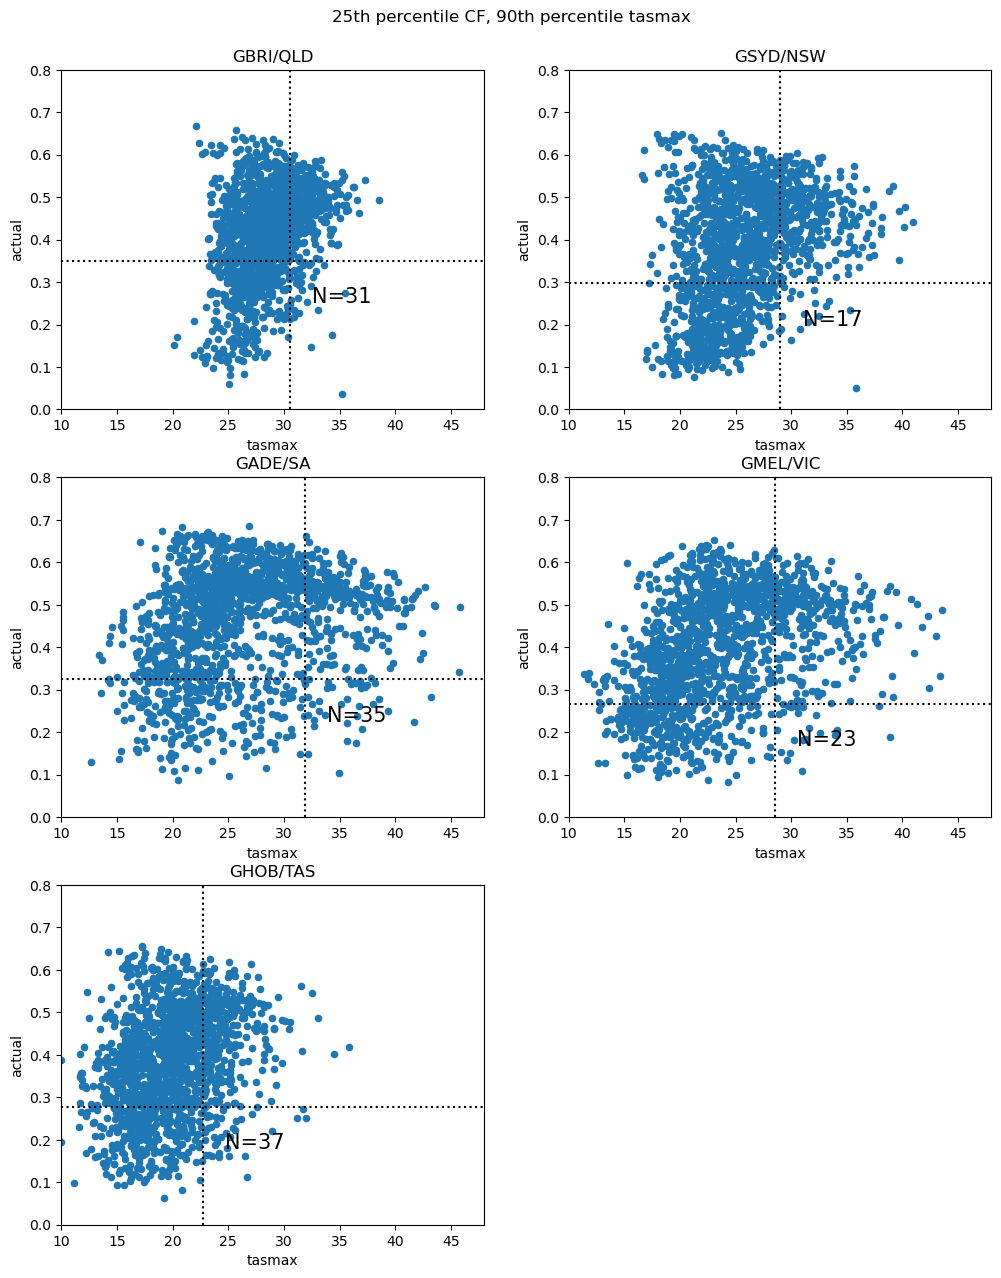

In [115]:
solar_regions = ["GBRI","GSYD","GADE","GMEL","GHOB"]
tasmax_regions = ["QLD","NSW","SA","VIC","TAS"]

plt.figure(figsize=[12,15])

cnt=1
for solar_region, tasmax_region in zip(solar_regions, tasmax_regions):
    ax=plt.subplot(3,2,cnt)
    solar_df = solar.sel(region=solar_region).actual.to_dataframe()
    solar_daily = solar_df["actual"].groupby(solar_df.index.date).mean()
    
    tasmax_df = tasmax.sel(region=tasmax_region).to_dataframe()
    tasmax_daily = tasmax_df["tasmax"].groupby(tasmax_df.index.date).max()
    
    df = pd.concat([tasmax_daily,solar_daily],axis=1,join="inner")
    df = df.iloc[np.in1d(pd.to_datetime(df.index).month, [11,12,1,2,3,4])]
    df.plot(x="tasmax",y="actual",kind="scatter",ax=ax)
    
    thresh_solar = solar_daily.quantile(0.25)
    thresh_tasmax = tasmax_daily.quantile(0.9)

    ax.axhline(thresh_solar,color="k",ls=":")
    ax.axvline(thresh_tasmax,color="k",ls=":")

    ax.text(
        thresh_tasmax + 2,
        thresh_solar - 0.1,
        "N="+str(df[(df.tasmax>thresh_tasmax) & (df.actual<thresh_solar)].shape[0]),size=15)

    plt.title(solar_region+"/"+tasmax_region)

    plt.ylim([0,0.8])
    plt.xlim([10,48])

    cnt=cnt+1

plt.suptitle("25th percentile CF, 90th percentile tasmax",y=0.92)

Text(0.5, 0.92, '50th percentile CF, 90th percentile tasmax')

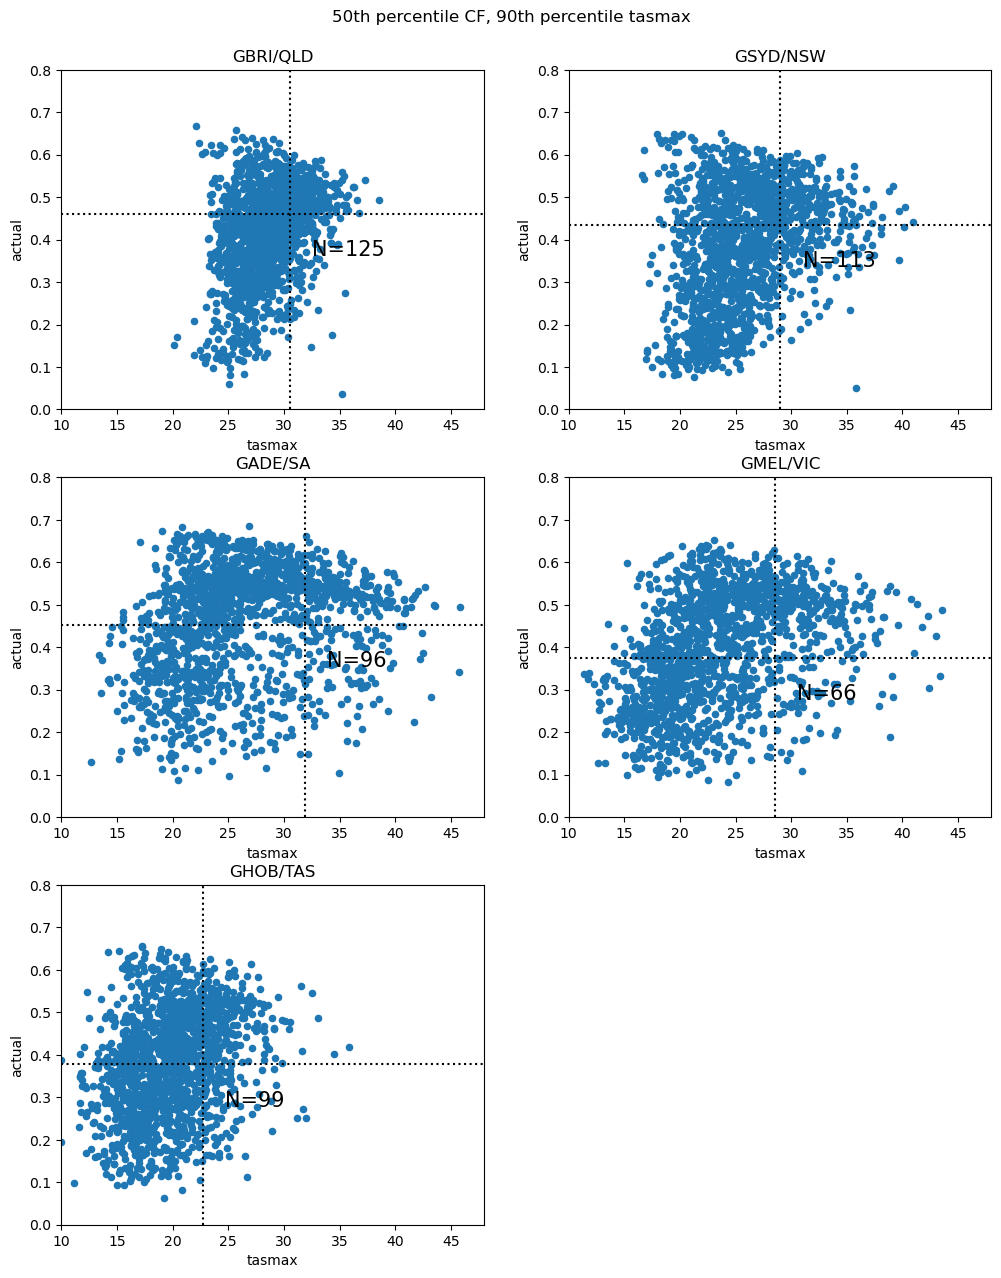

In [116]:
solar_regions = ["GBRI","GSYD","GADE","GMEL","GHOB"]
tasmax_regions = ["QLD","NSW","SA","VIC","TAS"]

plt.figure(figsize=[12,15])

cnt=1
for solar_region, tasmax_region in zip(solar_regions, tasmax_regions):
    ax=plt.subplot(3,2,cnt)
    solar_df = solar.sel(region=solar_region).actual.to_dataframe()
    solar_daily = solar_df["actual"].groupby(solar_df.index.date).mean()
    
    tasmax_df = tasmax.sel(region=tasmax_region).to_dataframe()
    tasmax_daily = tasmax_df["tasmax"].groupby(tasmax_df.index.date).max()
    
    df = pd.concat([tasmax_daily,solar_daily],axis=1,join="inner")

    df = df.iloc[np.in1d(pd.to_datetime(df.index).month, [11,12,1,2,3,4])]
    
    df.plot(x="tasmax",y="actual",kind="scatter",ax=ax)
    
    thresh_solar = solar_daily.quantile(0.5)
    thresh_tasmax = tasmax_daily.quantile(0.9)

    ax.axhline(thresh_solar,color="k",ls=":")
    ax.axvline(thresh_tasmax,color="k",ls=":")

    plt.ylim([0,0.8])
    plt.xlim([10,48])    

    ax.text(
        thresh_tasmax + 2,
        thresh_solar - 0.1,
        "N="+str(df[(df.tasmax>thresh_tasmax) & (df.actual<thresh_solar)].shape[0]),size=15)

    plt.title(solar_region+"/"+tasmax_region)

    cnt=cnt+1

plt.suptitle("50th percentile CF, 90th percentile tasmax",y=0.92)

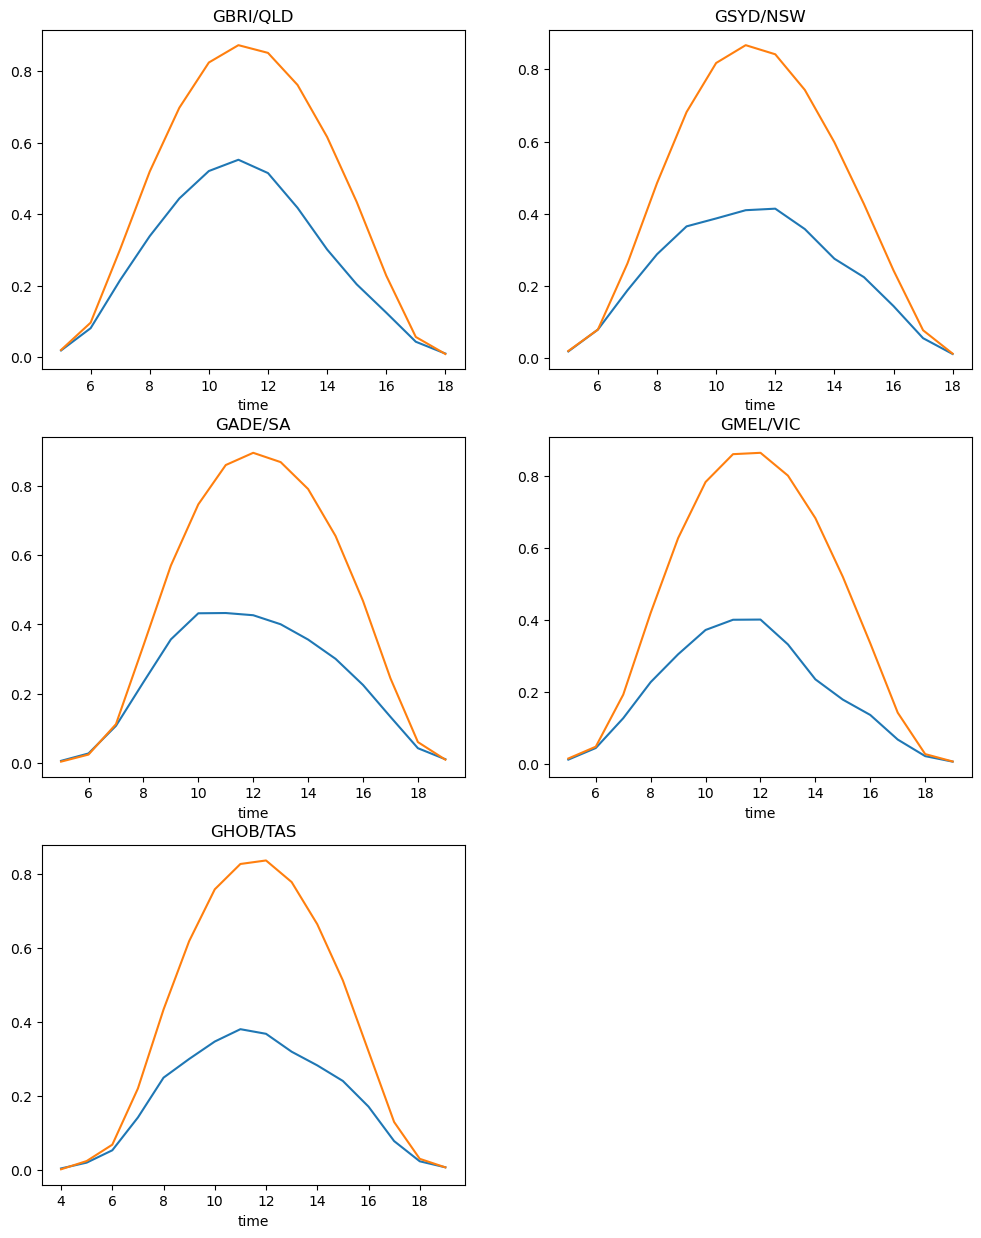

In [156]:
solar_regions = ["GBRI","GSYD","GADE","GMEL","GHOB"]
tasmax_regions = ["QLD","NSW","SA","VIC","TAS"]

plt.figure(figsize=[12,15])

cnt=1
for solar_region, tasmax_region in zip(solar_regions, tasmax_regions):
    ax=plt.subplot(3,2,cnt)


    solar_df = solar.sel(region=solar_region).actual.to_dataframe()
    solar_daily = solar_df["actual"].groupby(solar_df.index.date).mean()
    
    tasmax_df = tasmax.sel(region=tasmax_region).to_dataframe()
    tasmax_daily = tasmax_df["tasmax"].groupby(tasmax_df.index.date).max()
    
    df = pd.concat([tasmax_daily,solar_daily],axis=1,join="inner")
    df = df.iloc[np.in1d(pd.to_datetime(df.index).month, [11,12,1,2,3,4])]
    
    thresh_solar = solar_daily.quantile(0.25)
    thresh_tasmax = tasmax_daily.quantile(0.9)
    
    temp_df = df[(df.tasmax>thresh_tasmax) & (df.actual<thresh_solar)]
    target_days = pd.to_datetime(temp_df.index).date
    solar_hourly_target = solar_df.iloc[np.in1d(pd.to_datetime(solar_df.index).date, target_days)]
    
    temp_df = df[(df.tasmax>thresh_tasmax) & (df.actual>thresh_solar)]
    null_days = pd.to_datetime(temp_df.index).date
    solar_hourly_null = solar_df.iloc[np.in1d(pd.to_datetime(solar_df.index).date, null_days)]

    solar_hourly_target["actual"].groupby(solar_hourly_target.index.hour).mean().plot()
    solar_hourly_null["actual"].groupby(solar_hourly_null.index.hour).mean().plot()

    plt.title(solar_region+"/"+tasmax_region)

    cnt=cnt+1

#tasmax_hourly_target = tasmax_df.iloc[np.in1d(pd.to_datetime(tasmax_df.index).date, target_days)]

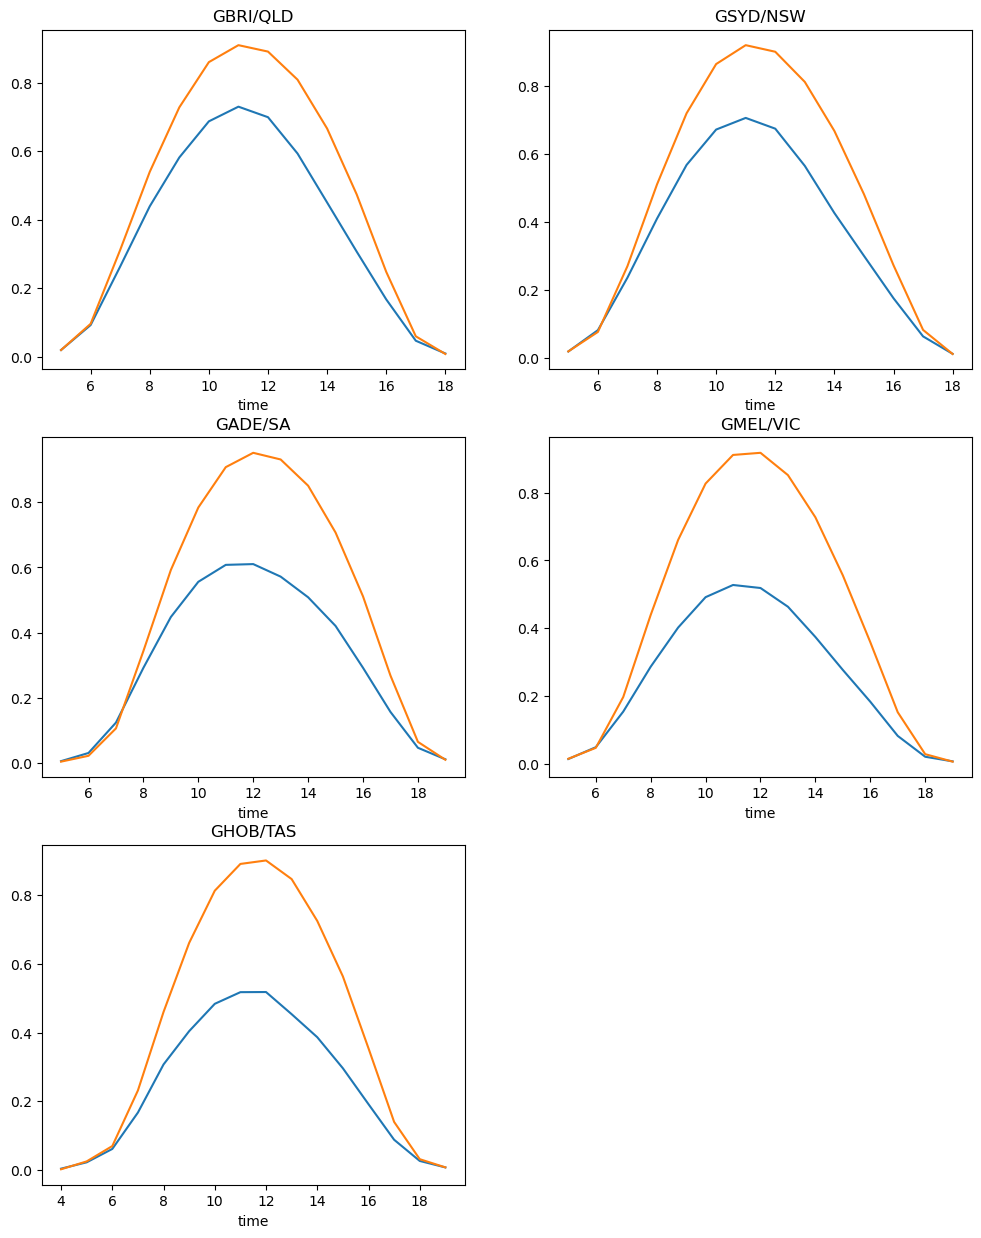

In [155]:
solar_regions = ["GBRI","GSYD","GADE","GMEL","GHOB"]
tasmax_regions = ["QLD","NSW","SA","VIC","TAS"]

plt.figure(figsize=[12,15])

cnt=1
for solar_region, tasmax_region in zip(solar_regions, tasmax_regions):
    ax=plt.subplot(3,2,cnt)


    solar_df = solar.sel(region=solar_region).actual.to_dataframe()
    solar_daily = solar_df["actual"].groupby(solar_df.index.date).mean()
    
    tasmax_df = tasmax.sel(region=tasmax_region).to_dataframe()
    tasmax_daily = tasmax_df["tasmax"].groupby(tasmax_df.index.date).max()
    
    df = pd.concat([tasmax_daily,solar_daily],axis=1,join="inner")
    df = df.iloc[np.in1d(pd.to_datetime(df.index).month, [11,12,1,2,3,4])]
    
    thresh_solar = solar_daily.quantile(0.5)
    thresh_tasmax = tasmax_daily.quantile(0.9)
    
    temp_df = df[(df.tasmax>thresh_tasmax) & (df.actual<thresh_solar)]
    target_days = pd.to_datetime(temp_df.index).date
    solar_hourly_target = solar_df.iloc[np.in1d(pd.to_datetime(solar_df.index).date, target_days)]
    
    temp_df = df[(df.tasmax>thresh_tasmax) & (df.actual>thresh_solar)]
    null_days = pd.to_datetime(temp_df.index).date
    solar_hourly_null = solar_df.iloc[np.in1d(pd.to_datetime(solar_df.index).date, null_days)]

    solar_hourly_target["actual"].groupby(solar_hourly_target.index.hour).mean().plot()
    solar_hourly_null["actual"].groupby(solar_hourly_null.index.hour).mean().plot()

    plt.title(solar_region+"/"+tasmax_region)

    cnt=cnt+1

#tasmax_hourly_target = tasmax_df.iloc[np.in1d(pd.to_datetime(tasmax_df.index).date, target_days)]

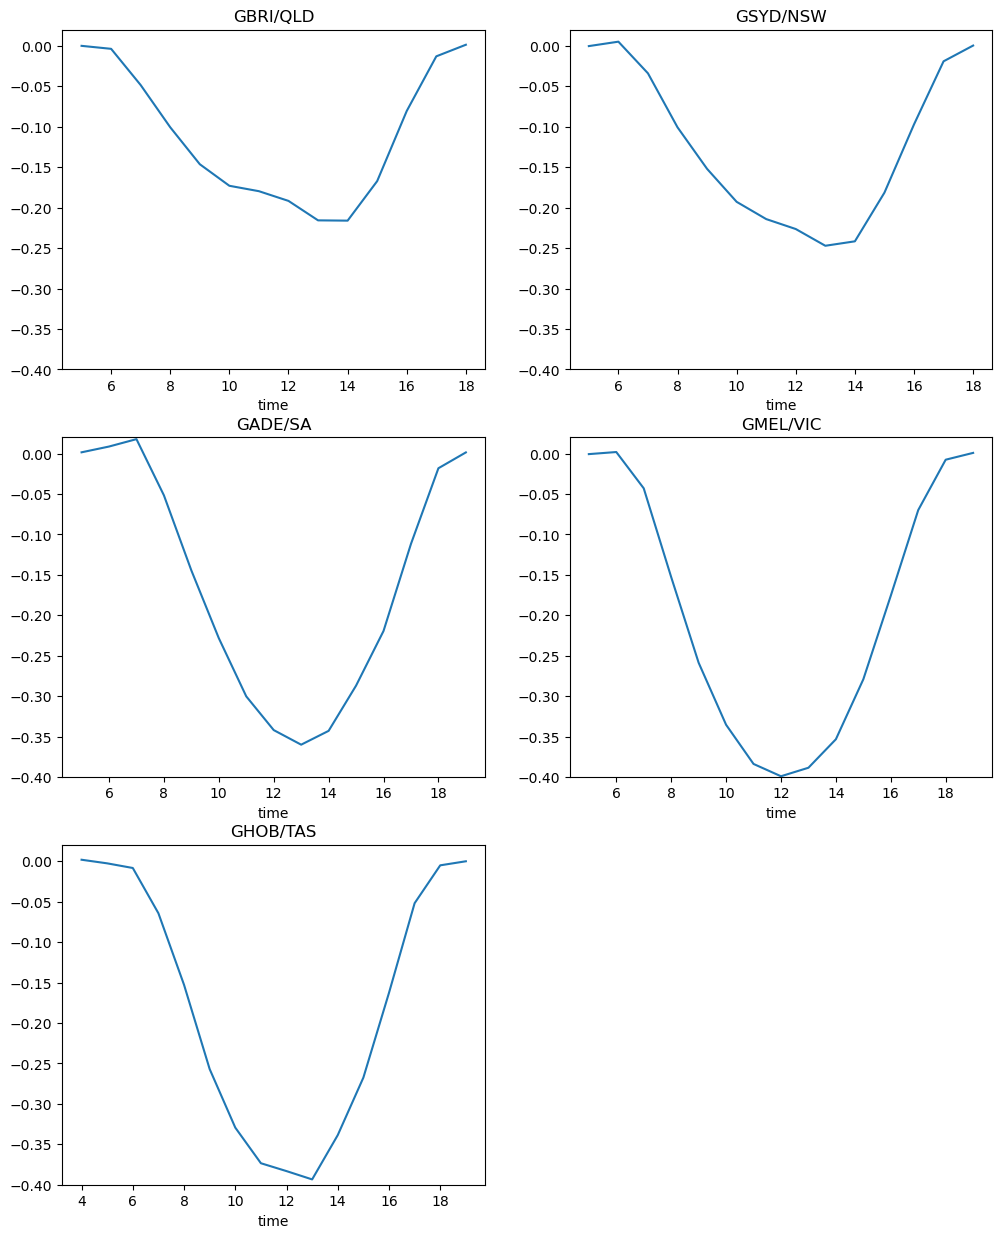

In [168]:
solar_regions = ["GBRI","GSYD","GADE","GMEL","GHOB"]
tasmax_regions = ["QLD","NSW","SA","VIC","TAS"]

plt.figure(figsize=[12,15])

cnt=1
for solar_region, tasmax_region in zip(solar_regions, tasmax_regions):
    ax=plt.subplot(3,2,cnt)


    solar_df = solar.sel(region=solar_region).actual.to_dataframe()
    solar_daily = solar_df["actual"].groupby(solar_df.index.date).mean()
    
    tasmax_df = tasmax.sel(region=tasmax_region).to_dataframe()
    tasmax_daily = tasmax_df["tasmax"].groupby(tasmax_df.index.date).max()
    
    df = pd.concat([tasmax_daily,solar_daily],axis=1,join="inner")
    df = df.iloc[np.in1d(pd.to_datetime(df.index).month, [11,12,1,2,3,4])]
    
    thresh_solar = solar_daily.quantile(0.5)
    thresh_tasmax = tasmax_daily.quantile(0.9)
    
    temp_df = df[(df.tasmax>thresh_tasmax) & (df.actual<thresh_solar)]
    target_days = pd.to_datetime(temp_df.index).date
    solar_hourly_target = solar_df.iloc[np.in1d(pd.to_datetime(solar_df.index).date, target_days)]
    
    temp_df = df[(df.tasmax>thresh_tasmax) & (df.actual>thresh_solar)]
    null_days = pd.to_datetime(temp_df.index).date
    solar_hourly_null = solar_df.iloc[np.in1d(pd.to_datetime(solar_df.index).date, null_days)]

    (solar_hourly_target["actual"].groupby(solar_hourly_target.index.hour).mean() -\
        solar_hourly_null["actual"].groupby(solar_hourly_null.index.hour).mean()).plot()

    plt.title(solar_region+"/"+tasmax_region)

    plt.ylim([-0.4,0.02])

    cnt=cnt+1

#tasmax_hourly_target = tasmax_df.iloc[np.in1d(pd.to_datetime(tasmax_df.index).date, target_days)]